In [1]:
# ─── Cellule 1 : Imports et chargement ────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

sys.path.append(os.path.join(os.getcwd(), "..", "src"))
from utils.config import DATA_PROCESSED, REPORTS_FIGURES

sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (14, 6)

# Charger les données nettoyées
chemin = os.path.join(DATA_PROCESSED, "crimes_clean.csv")
df = pd.read_csv(chemin, parse_dates=["Date"])

print(f"✅ Données chargées : {len(df):,} incidents | {df.shape[1]} colonnes")
print(f"   Période : {df['Date'].min().date()} → {df['Date'].max().date()}")

✅ Données chargées : 597,055 incidents | 22 colonnes
   Période : 2024-01-01 → 2026-06-19


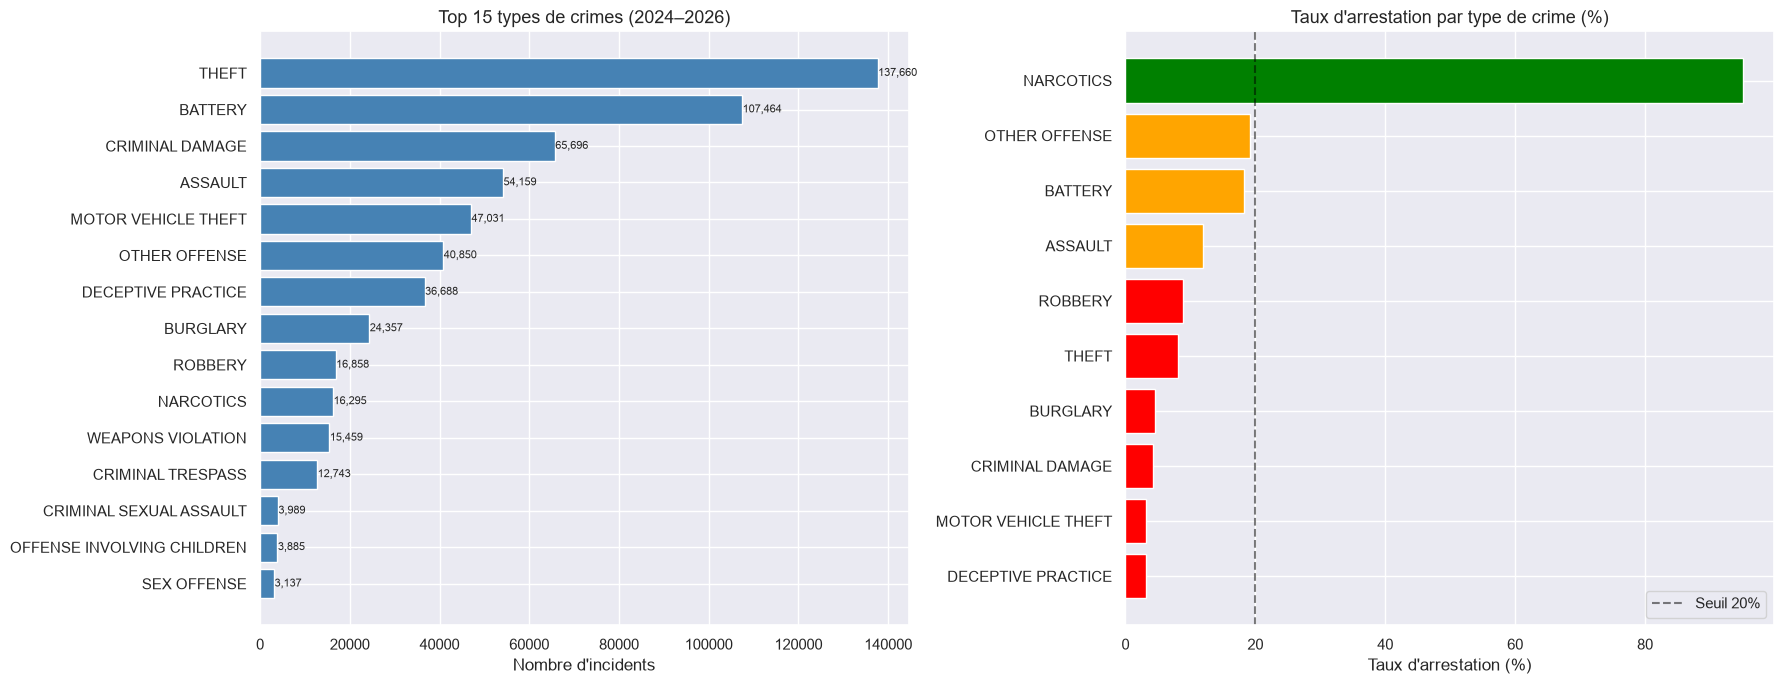

✅ Graphique sauvegardé


In [2]:
# ─── Cellule 2 : Analyse par type de crime ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── Top 15 crimes ─────────────────────────────────────────────────
top15 = df["Primary Type"].value_counts().head(15)
axes[0].barh(top15.index[::-1], top15.values[::-1], color="steelblue")
axes[0].set_title("Top 15 types de crimes (2024–2026)", fontsize=13)
axes[0].set_xlabel("Nombre d'incidents")
for i, v in enumerate(top15.values[::-1]):
    axes[0].text(v + 100, i, f"{v:,}", va="center", fontsize=8)

# ── Taux d'arrestation par type de crime ──────────────────────────
top10_crimes = df["Primary Type"].value_counts().head(10).index
df_top10 = df[df["Primary Type"].isin(top10_crimes)]
taux_arrestation = df_top10.groupby("Primary Type")["Arrest"].mean().sort_values()
couleurs = ["red" if x < 0.1 else "orange" if x < 0.2 else "green"
            for x in taux_arrestation.values]
axes[1].barh(taux_arrestation.index, taux_arrestation.values * 100, color=couleurs)
axes[1].set_title("Taux d'arrestation par type de crime (%)", fontsize=13)
axes[1].set_xlabel("Taux d'arrestation (%)")
axes[1].axvline(x=20, color="black", linestyle="--", alpha=0.5, label="Seuil 20%")
axes[1].legend()

plt.tight_layout()
os.makedirs(REPORTS_FIGURES, exist_ok=True)
plt.savefig(os.path.join(REPORTS_FIGURES, "analyse_types_crimes.png"), dpi=150, bbox_inches="tight")
plt.show()
print("✅ Graphique sauvegardé")

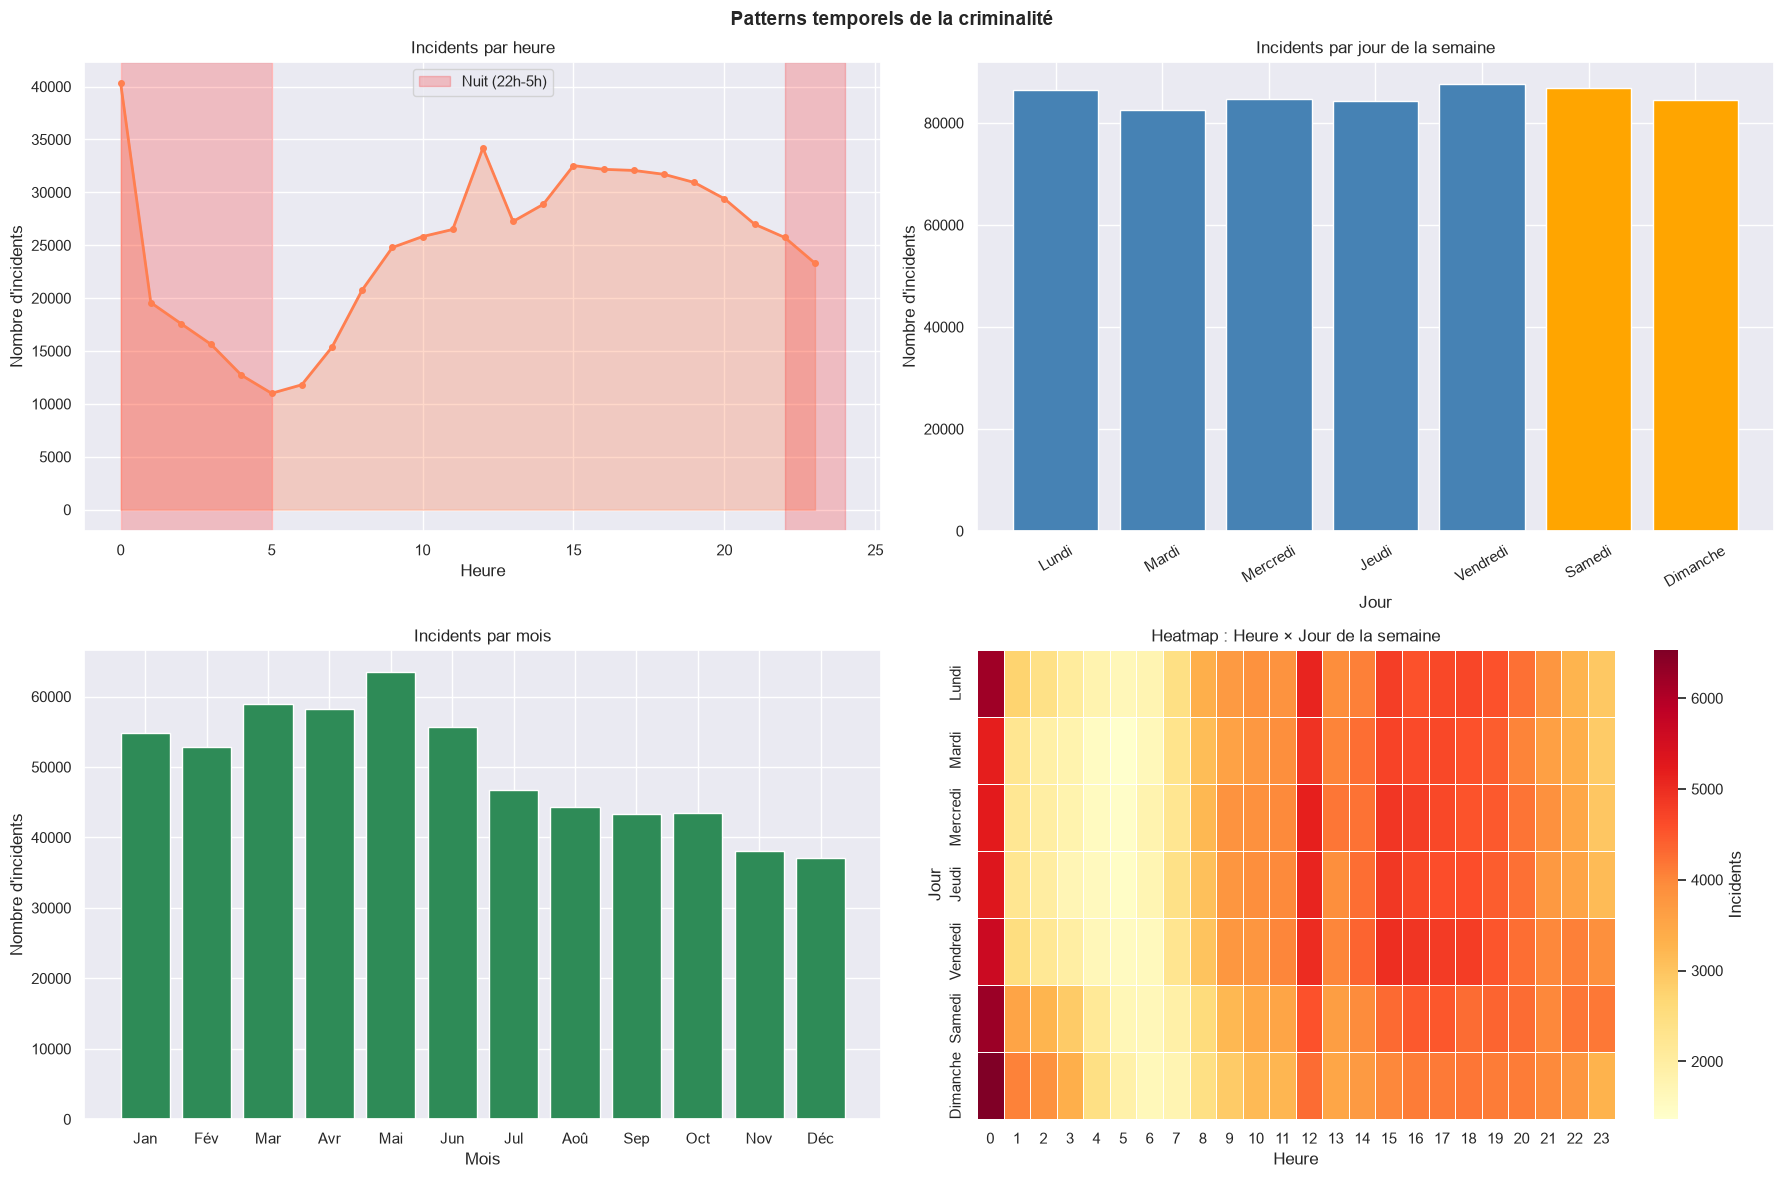

✅ Graphique sauvegardé


In [3]:
# ─── Cellule 3 : Analyse temporelle ───────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("Patterns temporels de la criminalité", fontsize=14, fontweight="bold")

# ── Par heure ─────────────────────────────────────────────────────
incidents_heure = df.groupby("heure").size()
axes[0, 0].plot(incidents_heure.index, incidents_heure.values,
                color="coral", linewidth=2, marker="o", markersize=4)
axes[0, 0].fill_between(incidents_heure.index, incidents_heure.values, alpha=0.3, color="coral")
axes[0, 0].set_title("Incidents par heure")
axes[0, 0].set_xlabel("Heure")
axes[0, 0].set_ylabel("Nombre d'incidents")
axes[0, 0].axvspan(22, 24, alpha=0.2, color="red", label="Nuit (22h-5h)")
axes[0, 0].axvspan(0, 5, alpha=0.2, color="red")
axes[0, 0].legend()

# ── Par jour de la semaine ────────────────────────────────────────
jours = ["Lundi", "Mardi", "Mercredi", "Jeudi", "Vendredi", "Samedi", "Dimanche"]
incidents_jour = df.groupby("jour_semaine").size()
couleurs_jours = ["steelblue"] * 5 + ["orange"] * 2
axes[0, 1].bar(jours, incidents_jour.values, color=couleurs_jours)
axes[0, 1].set_title("Incidents par jour de la semaine")
axes[0, 1].set_xlabel("Jour")
axes[0, 1].set_ylabel("Nombre d'incidents")
axes[0, 1].tick_params(axis="x", rotation=30)

# ── Par mois ──────────────────────────────────────────────────────
mois_noms = ["Jan", "Fév", "Mar", "Avr", "Mai", "Jun",
             "Jul", "Aoû", "Sep", "Oct", "Nov", "Déc"]
incidents_mois = df.groupby("mois").size()
axes[1, 0].bar(mois_noms[:len(incidents_mois)],
               incidents_mois.values, color="seagreen")
axes[1, 0].set_title("Incidents par mois")
axes[1, 0].set_xlabel("Mois")
axes[1, 0].set_ylabel("Nombre d'incidents")

# ── Heatmap heure x jour ──────────────────────────────────────────
pivot = df.groupby(["jour_semaine", "heure"]).size().unstack(fill_value=0)
pivot.index = jours
sns.heatmap(pivot, ax=axes[1, 1], cmap="YlOrRd",
            fmt="d", linewidths=0.5, cbar_kws={"label": "Incidents"})
axes[1, 1].set_title("Heatmap : Heure × Jour de la semaine")
axes[1, 1].set_xlabel("Heure")
axes[1, 1].set_ylabel("Jour")

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_FIGURES, "analyse_temporelle.png"), dpi=150, bbox_inches="tight")
plt.show()
print("✅ Graphique sauvegardé")

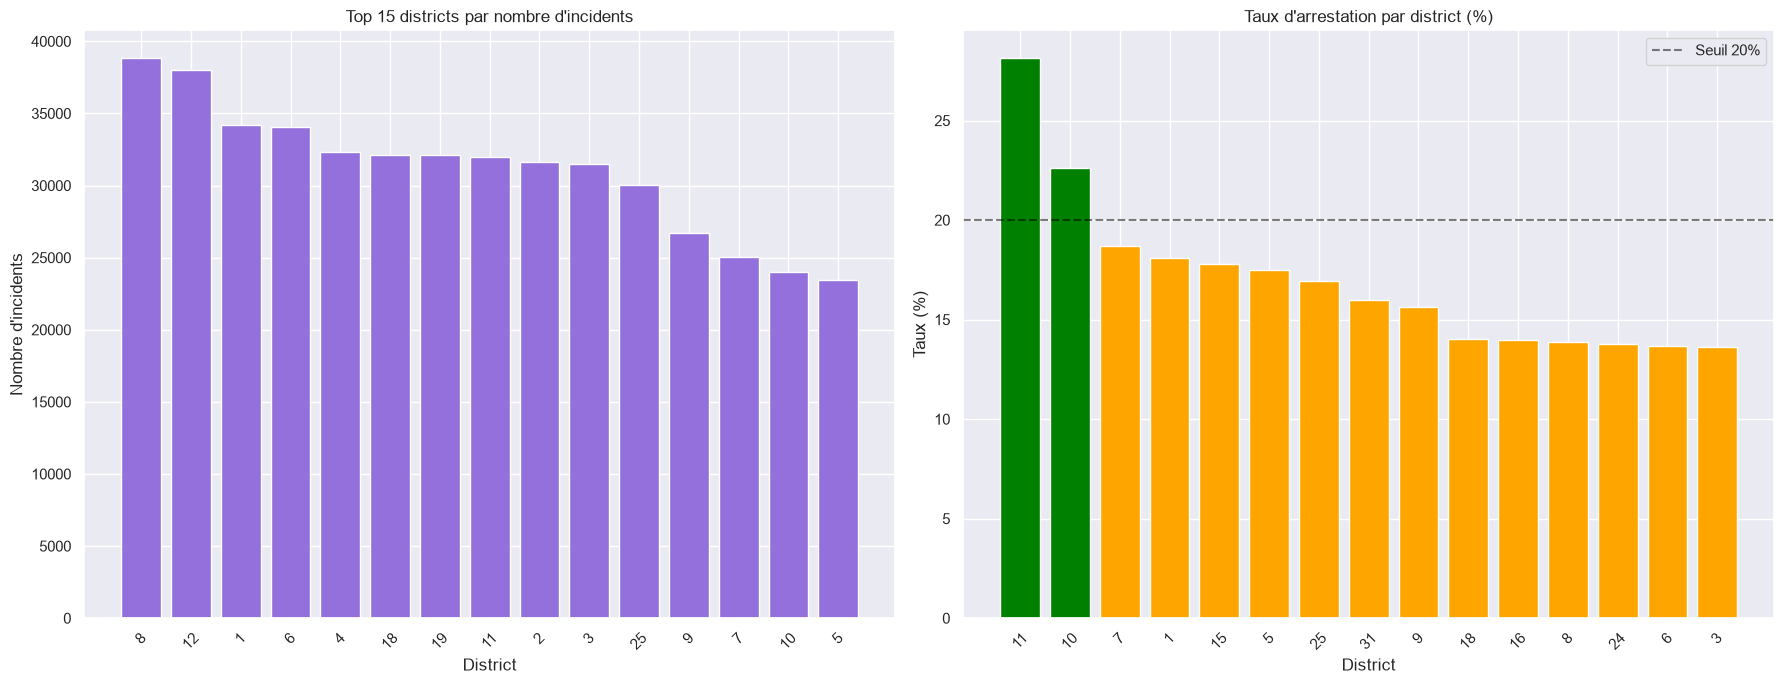

✅ Graphique sauvegardé


In [4]:
# ─── Cellule 4 : Analyse géographique ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── Incidents par district ────────────────────────────────────────
incidents_district = df.groupby("District").size().sort_values(ascending=False).head(15)
axes[0].bar(incidents_district.index.astype(str),
            incidents_district.values, color="mediumpurple")
axes[0].set_title("Top 15 districts par nombre d'incidents")
axes[0].set_xlabel("District")
axes[0].set_ylabel("Nombre d'incidents")
axes[0].tick_params(axis="x", rotation=45)

# ── Taux d'arrestation par district ──────────────────────────────
taux_district = df.groupby("District").agg(
    nb_incidents=("ID", "count"),
    nb_arrestations=("Arrest", "sum")
).reset_index()
taux_district["taux_arrestation"] = (
    taux_district["nb_arrestations"] / taux_district["nb_incidents"] * 100
)
taux_district = taux_district.sort_values("taux_arrestation", ascending=False).head(15)

couleurs = ["green" if x >= 20 else "orange" if x >= 10 else "red"
            for x in taux_district["taux_arrestation"]]
axes[1].bar(taux_district["District"].astype(str),
            taux_district["taux_arrestation"], color=couleurs)
axes[1].set_title("Taux d'arrestation par district (%)")
axes[1].set_xlabel("District")
axes[1].set_ylabel("Taux (%)")
axes[1].tick_params(axis="x", rotation=45)
axes[1].axhline(y=20, color="black", linestyle="--", alpha=0.5, label="Seuil 20%")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_FIGURES, "analyse_geographique.png"), dpi=150, bbox_inches="tight")
plt.show()
print("✅ Graphique sauvegardé")

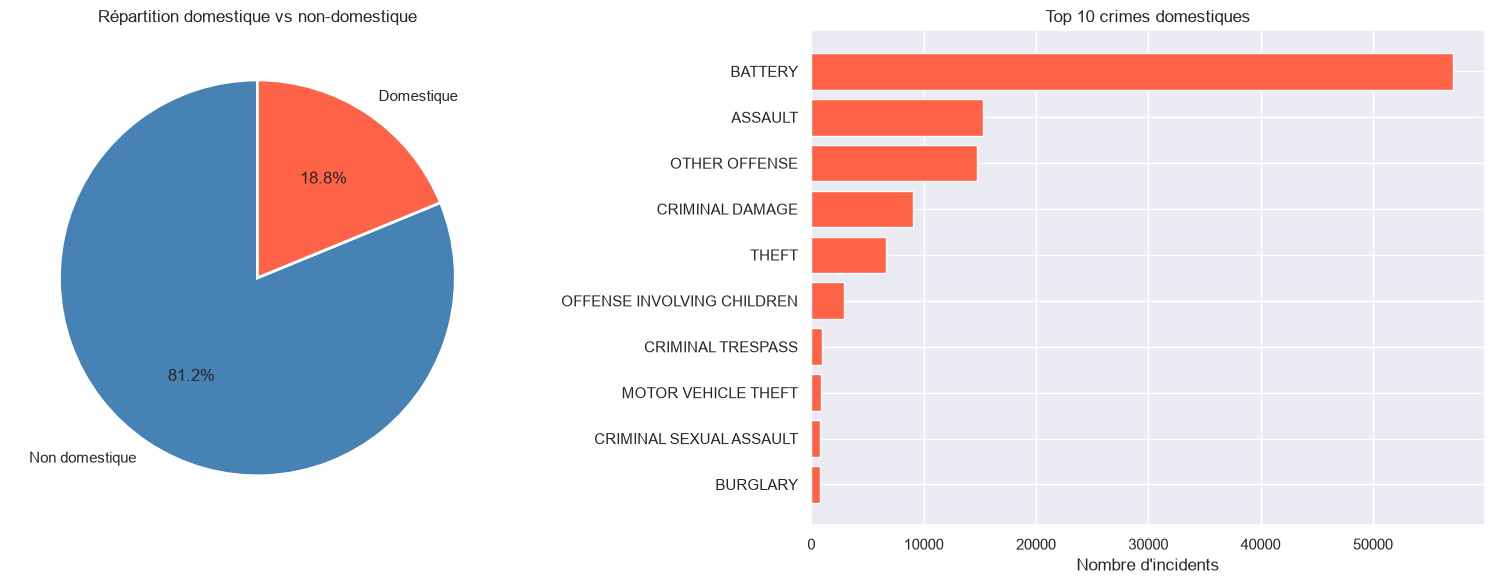

✅ Graphique sauvegardé


In [5]:
# ─── Cellule 5 : Criminalité domestique ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Répartition domestique vs non-domestique ──────────────────────
domestic_counts = df["Domestic"].value_counts()
labels = ["Non domestique", "Domestique"]
couleurs = ["steelblue", "tomato"]
axes[0].pie(domestic_counts.values, labels=labels, colors=couleurs,
            autopct="%1.1f%%", startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[0].set_title("Répartition domestique vs non-domestique")

# ── Top crimes domestiques ────────────────────────────────────────
top_domestic = (df[df["Domestic"] == True]["Primary Type"]
                .value_counts().head(10))
axes[1].barh(top_domestic.index[::-1], top_domestic.values[::-1], color="tomato")
axes[1].set_title("Top 10 crimes domestiques")
axes[1].set_xlabel("Nombre d'incidents")

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_FIGURES, "analyse_domestique.png"), dpi=150, bbox_inches="tight")
plt.show()
print("✅ Graphique sauvegardé")

In [6]:
# ─── Cellule 6 : Statistiques clés ───────────────────────────────
print("=" * 55)
print("  STATISTIQUES CLÉS — Chicago Crime 2024-2026")
print("=" * 55)

print(f"\n  📊 Volume")
print(f"     Total incidents       : {len(df):>10,}")
print(f"     Avec arrestation      : {df['Arrest'].sum():>10,} ({df['Arrest'].mean()*100:.1f}%)")
print(f"     Crimes domestiques    : {df['Domestic'].sum():>10,} ({df['Domestic'].mean()*100:.1f}%)")
print(f"     Crimes de nuit        : {df['est_nuit'].sum():>10,} ({df['est_nuit'].mean()*100:.1f}%)")
print(f"     Crimes le weekend     : {df['est_weekend'].sum():>10,} ({df['est_weekend'].mean()*100:.1f}%)")

print(f"\n  🗺️  Géographie")
print(f"     Nombre de districts   : {df['District'].nunique():>10}")
print(f"     District le + actif   : {df['District'].value_counts().index[0]:>10}")
print(f"     Community areas       : {df['Community Area'].nunique():>10}")

print(f"\n  🕐 Temporel")
print(f"     Heure la + criminelle : {df['heure'].value_counts().index[0]:>10}h")
print(f"     Mois le + criminel    : {df['mois'].value_counts().index[0]:>10}")
print(f"     Jour le + criminel    : {['Lundi','Mardi','Mercredi','Jeudi','Vendredi','Samedi','Dimanche'][df['jour_semaine'].value_counts().index[0]]:>10}")

print(f"\n  🔫 Criminalité")
print(f"     Type le + fréquent    : {df['Primary Type'].value_counts().index[0]:>10}")
print(f"     Nb types de crimes    : {df['Primary Type'].nunique():>10}")
print(f"     Lieu le + fréquent    : {df['Location Description'].value_counts().index[0]:>10}")

print("\n" + "=" * 55)

# Sauvegarder en CSV
stats = {
    "total_incidents": len(df),
    "taux_arrestation": round(df["Arrest"].mean() * 100, 2),
    "taux_domestique": round(df["Domestic"].mean() * 100, 2),
    "taux_nuit": round(df["est_nuit"].mean() * 100, 2),
    "nb_districts": int(df["District"].nunique()),
    "crime_principal": df["Primary Type"].value_counts().index[0],
}

import json
os.makedirs(os.path.join("..", "reports", "tables"), exist_ok=True)
with open(os.path.join("..", "reports", "tables", "stats_cles.json"), "w") as f:
    json.dump(stats, f, indent=2)
print("✅ Statistiques sauvegardées dans reports/tables/stats_cles.json")

  STATISTIQUES CLÉS — Chicago Crime 2024-2026

  📊 Volume
     Total incidents       :    597,055
     Avec arrestation      :     89,360 (15.0%)
     Crimes domestiques    :    112,210 (18.8%)
     Crimes de nuit        :    165,888 (27.8%)
     Crimes le weekend     :    171,382 (28.7%)

  🗺️  Géographie
     Nombre de districts   :         23
     District le + actif   :          8
     Community areas       :         77

  🕐 Temporel
     Heure la + criminelle :          0h
     Mois le + criminel    :          5
     Jour le + criminel    :   Vendredi

  🔫 Criminalité
     Type le + fréquent    :      THEFT
     Nb types de crimes    :         31
     Lieu le + fréquent    :     STREET

✅ Statistiques sauvegardées dans reports/tables/stats_cles.json


In [7]:
# ─── Feature Engineering ──────────────────────────────────────────
import pandas as pd
import numpy as np
import os, sys
sys.path.append(os.path.join(os.getcwd(), "..", "src"))
from utils.config import DATA_PROCESSED

df = pd.read_csv(os.path.join(DATA_PROCESSED, "crimes_clean.csv"), parse_dates=["Date"])

# ── 1. Encoder le type de crime en score de gravité ───────────────
gravite_crimes = {
    "HOMICIDE": 10, "CRIMINAL SEXUAL ASSAULT": 9, "ROBBERY": 8,
    "ASSAULT": 7, "BATTERY": 6, "BURGLARY": 6, "ARSON": 7,
    "KIDNAPPING": 9, "STALKING": 6, "HUMAN TRAFFICKING": 10,
    "MOTOR VEHICLE THEFT": 5, "THEFT": 4, "CRIMINAL DAMAGE": 4,
    "NARCOTICS": 5, "WEAPONS VIOLATION": 8, "PROSTITUTION": 3,
    "GAMBLING": 2, "LIQUOR LAW VIOLATION": 2, "OTHER OFFENSE": 3,
    "DECEPTIVE PRACTICE": 4, "CRIMINAL TRESPASS": 3,
    "INTERFERENCE WITH PUBLIC OFFICER": 3, "PUBLIC PEACE VIOLATION": 3,
    "OFFENSE INVOLVING CHILDREN": 9, "SEX OFFENSE": 8,
}
df["gravite"] = df["Primary Type"].map(gravite_crimes).fillna(3)
print(f"✅ Score de gravité créé (min={df['gravite'].min()}, max={df['gravite'].max()})")

# ── 2. Densité criminelle par district ────────────────────────────
densite_district = df.groupby("District").size()
densite_district = (densite_district - densite_district.min()) / (densite_district.max() - densite_district.min())
df["densite_district"] = df["District"].map(densite_district).fillna(0)
print(f"✅ Densité par district créée")

# ── 3. Densité criminelle par Community Area ──────────────────────
densite_area = df.groupby("Community Area").size()
densite_area = (densite_area - densite_area.min()) / (densite_area.max() - densite_area.min())
df["densite_area"] = df["Community Area"].map(densite_area).fillna(0)
print(f"✅ Densité par Community Area créée")

# ── 4. Score de risque composite ──────────────────────────────────
df["score_risque"] = (
    df["gravite"]          * 0.35 +
    df["densite_district"] * 10   * 0.25 +
    df["densite_area"]     * 10   * 0.20 +
    df["est_nuit"]         * 2    * 0.10 +
    df["est_weekend"]      * 1    * 0.10
)
# Normaliser entre 0 et 10
df["score_risque"] = (df["score_risque"] - df["score_risque"].min()) / \
                     (df["score_risque"].max() - df["score_risque"].min()) * 10
print(f"✅ Score de risque créé (min={df['score_risque'].min():.2f}, max={df['score_risque'].max():.2f})")

# ── 5. Niveau de risque (cible ML) ────────────────────────────────
def classifier_risque(score):
    if score >= 6.5: return 2   # Rouge  — Élevé
    elif score >= 3.5: return 1 # Orange — Moyen
    else: return 0              # Vert   — Faible

df["niveau_risque"] = df["score_risque"].apply(classifier_risque)
counts = df["niveau_risque"].value_counts().sort_index()
print(f"✅ Niveau de risque créé :")
print(f"   🟢 Faible (0) : {counts.get(0,0):>8,}")
print(f"   🟠 Moyen  (1) : {counts.get(1,0):>8,}")
print(f"   🔴 Élevé  (2) : {counts.get(2,0):>8,}")

# ── 6. Encoder Primary Type en numérique ──────────────────────────
df["crime_type_code"] = df["Primary Type"].astype("category").cat.codes
print(f"✅ Crime type encodé ({df['crime_type_code'].nunique()} catégories)")

# ── 7. Encoder Location Description ──────────────────────────────
df["location_code"] = df["Location Description"].astype("category").cat.codes
print(f"✅ Location encodée ({df['location_code'].nunique()} catégories)")

# ── Sauvegarder ───────────────────────────────────────────────────
chemin = os.path.join(DATA_PROCESSED, "crimes_features.csv")
df.to_csv(chemin, index=False)
taille = os.path.getsize(chemin) / (1024*1024)
print(f"\n✅ Sauvegardé : crimes_features.csv ({taille:.1f} Mo | {len(df):,} lignes | {df.shape[1]} colonnes)")

✅ Score de gravité créé (min=2.0, max=10.0)
✅ Densité par district créée
✅ Densité par Community Area créée
✅ Score de risque créé (min=0.00, max=10.00)
✅ Niveau de risque créé :
   🟢 Faible (0) :   95,977
   🟠 Moyen  (1) :  433,885
   🔴 Élevé  (2) :   67,193
✅ Crime type encodé (31 catégories)
✅ Location encodée (135 catégories)


Task was destroyed but it is pending!
task: <Task pending name='Task-175' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\RiskMap_AI\venv\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-176' coro=<Kernel.shell_main() running at C:\RiskMap_AI\venv\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\RiskMap_AI\venv\Lib\site-packages\zmq\eventloop\zmqstream.py:563]>
C:\RiskMap_AI\venv\Lib\site-packages\pandas\io\formats\csvs.py:330: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  libwriters.write_csv_rows(
Task was destroyed but it is pending!
task: <Task pending name='Task-176' coro=<Kernel.shell_main() running at C:\RiskMap_AI\venv\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]>



✅ Sauvegardé : crimes_features.csv (134.9 Mo | 597,055 lignes | 29 colonnes)
